# Data Collection & Indicator calucation

In [274]:
from sklearn.exceptions import DataConversionWarning
import warnings

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DataConversionWarning)

In [275]:
import pandas as pd
import numpy as np

data = pd.read_csv("/Users/sonlamtong/Desktop/Python/Thesis/Technical Analysis /Data Set/vcb_Training_Data.csv")
'''
data = data.set_index("Date")
'''
data.rename(columns={'Unnamed: 0': 'time'}, inplace=True)
data.set_index("time", inplace=True)

training_data = data.loc[:, ~data.columns.isin(["target", "strength target", "regression target"])].copy()
target= data.loc[:, ["target"]].copy()

display(training_data.shape, target.shape)
display(data)

(2367, 108)

(2367, 1)

,open,high,low,close,volume,vnindex,vn30,hnx,gold,oil,...,momentum_ppo_signal,momentum_ppo_hist,momentum_pvo,momentum_pvo_signal,momentum_pvo_hist,momentum_kama,others_dr,others_dlr,others_cr,target
time,,,,,,,,,,,,,,,,,,,,,
2015-11-16,14.25,14.40,14.19,14.25,426970.0,609.21,619.14,81.05,1083.699951,43.580002,...,0.881119,-0.207515,-3.104510,3.271574,-6.376084,14.115983,-1.556971,-1.569219,11.741835,1.0
2015-11-17,14.25,14.52,14.22,14.28,448710.0,605.05,614.39,81.14,1068.699951,43.570000,...,0.790877,-0.360965,-2.384450,2.140370,-4.524819,14.207312,-1.294033,-1.302479,10.808709,1.0
2015-11-18,14.22,14.37,14.22,14.28,302580.0,603.34,612.25,81.36,1068.800049,44.139999,...,0.683069,-0.431232,-7.209824,0.270331,-7.480155,14.277276,0.436999,0.436047,11.041991,0.0
2015-11-19,14.34,14.34,14.19,14.22,359250.0,601.90,609.05,81.24,1078.000000,44.180000,...,0.571935,-0.444538,-12.017176,-2.187171,-9.830006,14.299412,1.377810,1.368405,11.041991,0.0
2015-11-20,14.22,14.31,14.22,14.22,268060.0,604.46,611.16,81.59,1076.400024,44.660000,...,0.474137,-0.391191,-15.337819,-4.817300,-10.520519,14.314468,1.502146,1.490975,10.575428,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-21,63.30,65.00,63.30,64.20,9639300.0,1688.00,1874.91,284.39,3336.899902,67.669998,...,-0.171033,0.423546,10.083656,2.077334,8.006321,61.427762,0.000000,0.000000,389.891135,1.0
2025-08-22,64.00,67.20,63.70,64.60,18944300.0,1645.47,1814.02,272.48,3374.399902,67.730003,...,-0.056238,0.459181,9.402578,3.542383,5.860195,61.430353,-0.161031,-0.161160,399.222395,0.0
2025-08-25,65.80,65.80,63.40,63.60,7750800.0,1614.03,1783.12,266.58,3373.800049,68.800003,...,0.063700,0.479751,13.820402,5.597987,8.222415,61.439830,1.290323,1.282069,402.332815,1.0


## Data Preparation:

In [276]:
def data_split(split_percentage, df):

    assert 0 < split_percentage < 1, "split_percentage must be a float between 0 and 1 (exclusive)"
    
    split_index = int(len(df) * split_percentage)

    train_df = df.iloc[:split_index].copy()
    test_df = df.iloc[split_index:].copy()
    
    return train_df, test_df

In [277]:
from sklearn.model_selection import train_test_split

def define_rule_based_indicators_list(X):
    rule_based_indicators =[]
    for col in X.columns:
        if len(X[col].unique()) <= 2:
            rule_based_indicators.append(col)
    
    return rule_based_indicators

print(define_rule_based_indicators_list(training_data))

#X, Valid_set, y, Valid_result = data_split(split_percentage=0.8, df=training_data.reset_index(drop=True))
X, Valid_set = data_split(split_percentage=0.8, df=training_data.reset_index(drop=True))
y, Valid_result = target.reset_index(drop=True).loc[X.index], target.reset_index(drop=True).loc[Valid_set.index]

['hour', 'minute', 'minute_segment', 'monday_morning', 'friday_afternoon', 'pre_holiday_afternoon', 'post_holiday_morning', 'volatility_bbhi', 'volatility_bbli', 'volatility_kchi', 'volatility_kcli', 'trend_psar_up_indicator', 'trend_psar_down_indicator']


Text(0, 0.5, 'Price')

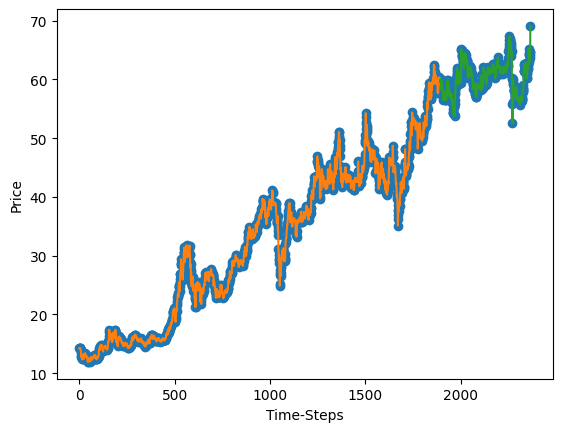

In [278]:
from matplotlib import pyplot as plt

df = training_data.reset_index(drop=True)
price = df.loc[:, 'close']
plt.plot(price.index, price.values, 'o')

for df in [X, Valid_set]:
    price = df.loc[:, 'close']
    plt.plot(price.index, price.values)
    
plt.xlabel("Time-Steps")
plt.ylabel("Price")

## Scoring for Tuning and Optimization:

In [279]:
#scoring = "accuracy"
scoring = "f1"

### GMM model import:

In [280]:
import joblib
from sklearn.mixture import GaussianMixture

package = joblib.load(f"/Users/sonlamtong/Desktop/Python/Thesis/Technical Analysis /ML models/prediction dataset/Classification/gmm_model_with_threshold.pkl")

gmm_model = package["model"]
gmm_array = package["array"]

gmm_model, gmm_array

(GaussianMixture(n_components=4, random_state=42), 'log_return')

### MSM model import:

In [281]:
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
import joblib

package = joblib.load(f"/Users/sonlamtong/Desktop/Python/Thesis/Technical Analysis /ML models/prediction dataset/Classification/msm_model_with_threshold.pkl")

msm_model = MarkovRegression(**package)

### Fold CV fucntion:

In [282]:
def purged_kfold_split(X, n_splits=5, lookahead=5, embargo=0):
    fold_size = len(X) // n_splits
    for i in range(n_splits):
        test_start = i * fold_size
        test_end = (i + 1) * fold_size

        # Embargo
        embargo_start = test_end + 1
        embargo_end = embargo_start + embargo

        # Purge overlaps
        train_idx = list(range(0, test_start - lookahead)) + list(range(embargo_end, len(X)))
        test_idx = list(range(test_start, test_end))

        yield train_idx, test_idx

### Model Evaluation:

In [ ]:

from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import f1_score, classification_report, accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.utils.class_weight import compute_sample_weight

def Evaluation_for_Testing_part(model, X=X.copy(), y=y.copy(), Valid_set=Valid_set.copy(), Valid_result=Valid_result.copy(), threshold=False):
    X_train_1 = X.copy()
    y_train_1 = y.copy()
    X_test_1 = Valid_set.copy()
    y_test_1 = Valid_result.copy()
    
    if threshold == False:
        pass
    else:
        print(f"The Best Threshold: {threshold}")
    
    '''
    res = msm_model.fit(disp=False, maxiter=500)
    proba = res.smoothed_marginal_probabilities
    proba = np.asarray(proba) if isinstance(proba, list) else proba  # guard for older versions
    regimes = proba.idxmax(axis=1).astype(int)
    '''    
    
    f1_array_macro = []
    acc_array = []
    for fold_idx, (train_idx, test_idx) in enumerate(purged_kfold_split(X_train_1.copy())):
        X_train, X_test = X_train_1.iloc[train_idx], X_train_1.iloc[test_idx]
        y_train, y_test = y_train_1.iloc[train_idx], y_train_1.iloc[test_idx]
        
        X_train = Ensemble_Feature_Selection(model=model, X=X_train.copy(), y=y_train)
        X_test = X_test.loc[:, X_train.columns.tolist()]
        
        gmm_model.fit(X.iloc[train_idx][[gmm_array]].copy())
        train_regime = gmm_model.predict(X.iloc[train_idx][[gmm_array]].copy())
        test_regime = gmm_model.predict(X.iloc[test_idx][[gmm_array]].copy())
        
        '''
        train_regime, test_regime = regimes.loc[X_train.index], regimes[X_test.index]
        '''
        
        the_final_ypred = np.zeros(len(X_test))
        the_final_yproba = np.zeros(len(X_test))
        for regime in np.unique(test_regime):

            '''
            X_train_res, y_train_res = X_train, y_train
            X_test_res, y_test_res = X_test, y_test
            '''
            X_train_res, y_train_res = X_train.loc[train_regime == regime], y_train.loc[train_regime == regime]
            X_test_res, y_test_res = X_test.loc[test_regime == regime], y_test.loc[test_regime == regime]
            
            if len(np.unique(y_train_res)) < 2:
                '''
                y_pred = np.zeros(len(X_test_res)) if np.unique(y_train_res) == 0 else np.ones(len(X_test_res))
                the_final_ypred[test_regime == regime] = y_pred
                the_final_yproba[test_regime == regime] = np.zeros(len(X_test_res))
                continue
                '''

            # Calibrated model training
            '''
            calibrated_model = CalibratedClassifierCV(model, method='isotonic', cv=5)
            calibrated_model.fit(X_train_res, y_train_res)
            '''
            model.fit(X_train_res, y_train_res)
            
            if threshold == False:
                '''
                y_pred = calibrated_model.predict(X_test_res)
                '''
                y_pred = model.predict(X_test_res)
                '''
                the_final_ypred = y_pred
                '''
                the_final_ypred[test_regime == regime] = y_pred
            else:
                '''
                y_proba = calibrated_model.predict_proba(X_test_res)[:, 1] # Probabilities
                '''
                y_proba = model.predict_proba(X_test_res)[:, 1]
                '''
                the_final_yproba = y_proba
                '''
                the_final_yproba[test_regime == regime] = y_proba
                y_pred = np.where(y_proba >= threshold, 1, 0)
                '''
                the_final_ypred = y_pred
                '''
                the_final_ypred[test_regime == regime] = y_pred
        if not isinstance(threshold, bool):
            y_test = pd.DataFrame(y_test)
            plt.hist(the_final_yproba[np.array(y_test).T[0]==0], bins=50, alpha=0.5, label='Class 0')
            plt.hist(the_final_yproba[np.array(y_test).T[0]==1], bins=50, alpha=0.5, label='Class 1')
            plt.axvline(x= threshold, linestyle="--", linewidth=3, color="black")
            plt.legend()
            #plt.title(f"Probability Distribution by True Class by regime {regime}")
            plt.show()

        # Evaluation
        print(f"Fold {fold_idx + 1}")
        print(f"Train: {np.unique(y_train, return_counts=True)}")
        print(f"Test: {np.unique(y_test, return_counts=True)}")
        print(f"Prediction: {np.unique(the_final_ypred, return_counts=True)}, F1: {f1_score(y_true=y_test, y_pred=the_final_ypred):.2f}, Accurancy: {accuracy_score(y_true=y_test, y_pred=the_final_ypred)}")
        print()
        
        # Append scores
        f1_array_macro.append(f1_score(y_true=y_test, y_pred=the_final_ypred))
        acc_array.append(accuracy_score(y_true=y_test, y_pred=the_final_ypred))
        
    X_train_1 = Ensemble_Feature_Selection(model=model, X=X_train_1, y=y_train_1)
    X_test_1 = X_test_1.loc[:, X_train_1.columns.tolist()]
    '''
    train_regime, test_regime = regimes[X_train_1.index], regimes[X_test_1.index]
    '''
    
    gmm_model.fit(X[[gmm_array]].copy())
    train_regime = gmm_model.predict(X[[gmm_array]].copy())
    test_regime = gmm_model.predict(Valid_set[[gmm_array]].copy())
    
    the_final_ypred = np.zeros(len(X_test_1))
    the_final_yproba = np.zeros(len(X_test_1))
    
    for regime in np.unique(test_regime):
        X_train_res, y_train_res = X_train_1.loc[train_regime == regime], y_train_1.loc[train_regime == regime]
        X_test_res, y_test_res = X_test_1.loc[test_regime == regime], y_test_1.loc[test_regime == regime]
        '''
        X_train_res, y_train_res = X_train_1, y_train_1
        X_test_res, y_test_res = X_test_1, y_test_1
        '''

        if len(np.unique(y_train_res)) < 2:
            '''
            y_pred_1 = np.zeros(len(X_test_res)) if np.unique(y_train_res) == 0 else np.ones(len(X_test_res))
            the_final_ypred[test_regime == regime] = y_pred_1
            continue
            '''

        model.fit(X_train_res, y_train_res)
        if isinstance(threshold, bool):
            '''
            y_pred_1 = calibrated_model.predict(X_test_res)
            '''
            y_pred_1 = model.predict(X_test_res)
            '''
            the_final_ypred = y_pred_1
            '''
            the_final_ypred[test_regime == regime] = y_pred_1
        else:
            '''
            y_proba_1 = calibrated_model.predict_proba(X_test_res)[:, 1] # Probabilities
            '''
            y_proba_1 = model.predict_proba(X_test_res)[:, 1] # Probabilities
            '''
            the_final_yproba = y_proba_1
            '''
            the_final_yproba[test_regime == regime] = y_proba_1
            y_pred_1 = np.where(y_proba_1 >= threshold, 1, 0)
            '''
            the_final_ypred = y_pred_1
            '''
            the_final_ypred[test_regime == regime] = y_pred_1
        
    if not isinstance(threshold, bool):
        y_test_1 = pd.DataFrame(y_test_1)
        plt.hist(the_final_yproba[np.array(y_test_1).T[0]==0], bins=50, alpha=0.5, label='Class 0')
        plt.hist(the_final_yproba[np.array(y_test_1).T[0]==1], bins=50, alpha=0.5, label='Class 1')
        plt.axvline(x= threshold, linestyle="--", linewidth=3, color="black")
        plt.legend()
        #plt.title(f"Probability Distribution by True Class by regime {regime}")
        plt.show()

    print()
    print(f"Train: {np.unique(y_train_1, return_counts=True)}")
    print(f"Test: {np.unique(y_test_1, return_counts=True)}")
    print(f"Prediction: {np.unique(the_final_ypred, return_counts=True)}")
    print(len(the_final_ypred), len(y_test_1))

    # Optional: print average results
    print()
    print(f"F1: train_cv-{np.mean(f1_array_macro)} test-{f1_score(y_true=y_test_1, y_pred=the_final_ypred)}")
    print(f"Accurancy: train_cv-{np.mean(acc_array)} test-{accuracy_score(y_true=y_test_1, y_pred=the_final_ypred)}")
    print(classification_report(y_true=y_test_1, y_pred=the_final_ypred))

def evaluation_for_tuning(model, X, y):
    X_train_1 = X.copy()
    y_train_1 = y.copy()
    
    '''
    res = msm_model.fit(disp=False, maxiter=500)
    proba = res.smoothed_marginal_probabilities
    proba = np.asarray(proba) if isinstance(proba, list) else proba  # guard for older versions
    regimes = proba.idxmax(axis=1).astype(int)
    '''

    f1_array_macro = []
    acc_array = []
    for fold_idx, (train_idx, test_idx) in enumerate(purged_kfold_split(X_train_1.copy())):
        X_train, X_test = X_train_1.iloc[train_idx], X_train_1.iloc[test_idx]
        y_train, y_test = y_train_1.iloc[train_idx], y_train_1.iloc[test_idx]
        
        X_train = Ensemble_Feature_Selection(model=model, X=X_train.copy(), y=y_train)
        X_test = X_test.loc[:, X_train.columns.tolist()]
        
        gmm_model.fit(X.iloc[train_idx][[gmm_array]].copy())
        train_regime = gmm_model.predict(X.iloc[train_idx][[gmm_array]].copy())
        test_regime = gmm_model.predict(X.iloc[test_idx][[gmm_array]].copy())
        
        '''
        train_regime, test_regime = regimes.loc[X_train.index], regimes[X_test.index]
        '''
        the_final_ypred = np.zeros(len(X_test))
        for regime in np.unique(test_regime):
            X_train_res, y_train_res = X_train.loc[train_regime == regime], y_train.loc[train_regime == regime]
            X_test_res, y_test_res = X_test.loc[test_regime == regime], y_test.loc[test_regime == regime]
        
            '''
            X_train_res, y_train_res = X_train, y_train
            X_test_res, y_test_res = X_test, y_test
            '''
            
            if len(np.unique(y_train_res)) < 2:
                '''
                y_pred = np.zeros(len(X_test_res)) if np.unique(y_train_res) == 0 else np.ones(len(X_test_res))
                the_final_ypred[test_regime == regime] = y_pred
                continue
                '''
            # Calibrated model training
            model.fit(X_train_res, y_train_res)
            y_pred = model.predict(X_test_res)
            '''
            the_final_ypred = y_pred
            '''
            the_final_ypred[test_regime == regime] = y_pred
            
        # Append scores
        f1_array_macro.append(f1_score(y_true=y_test, y_pred=the_final_ypred))
        acc_array.append(accuracy_score(y_true=y_test, y_pred=the_final_ypred))
    
    return np.mean(f1_array_macro)

    
def evaluation_score_test(base_model, X_train_1, y_train_1):
    cv = purged_kfold_split(X_train_1.copy())
    '''
    calibrated_model = CalibratedClassifierCV(base_model, method='isotonic', cv=5)
    calibrated_model.fit(X_train_1, y_train_1)
    scores = cross_val_score(estimator=calibrated_model, X=X_train_1.copy(), y=y_train_1.copy(), cv=cv, scoring=scoring, n_jobs=-1)
    '''
    scores = cross_val_score(estimator=base_model, X=X_train_1.copy(), y=y_train_1.copy(), cv=cv, scoring=scoring, n_jobs=-1)
    return np.mean(scores)

# Feature Filter functions:

In [284]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, mutual_info_classif, chi2, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from statsmodels.stats.outliers_influence import variance_inflation_factor
from xgboost import XGBClassifier
from boruta import BorutaPy
import shap
from scipy.stats import wilcoxon

# ---------------------------
# Feature Selection Functions
# ---------------------------

def low_variance_filter(X, threshold=1e-4):
    selector = VarianceThreshold(threshold=threshold)
    selector.fit(X)
    return X.columns[selector.get_support()]

def mi_filter(X, y, threshold=1e-4):
    mi = mutual_info_classif(X, y)
    selected = X.columns[mi > threshold]
    return selected

def feature_importances(X, y, model):
    model.fit(X, y)
    return X.columns[model.feature_importances_ > 0]

def correlation_filter(X, threshold=0.95):
    corr_matrix = X.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    return X.drop(columns=to_drop).columns

def f_test_pvalue_filter(X, y, alpha=0.05):
    selector = SelectKBest(score_func=f_classif, k='all')
    selector.fit(X, y)
    return X.columns[selector.pvalues_ < alpha]

def boruta_filter(X, y, model):
    feat_selector = BorutaPy(model, n_estimators='auto', verbose=0, random_state=42)
    feat_selector.fit(X.values, y.values)
    return X.columns[feat_selector.support_]

def rfe_filter(X, y, model, n_features_to_select=10):
    selector = RFE(estimator=model, n_features_to_select=n_features_to_select, step=1)
    selector.fit(X, y)
    return X.columns[selector.support_]

def shap_filter(X, y, model, threshold=0.01):
    model.fit(X, y)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)

    mean_abs_shap = np.abs(shap_values).mean(axis=0)

    #print(mean_abs_shap, X.columns.to_numpy())
    selected_features = X.columns.to_numpy()[mean_abs_shap > threshold]
    return selected_features

def permutation_importance_filter(X, y, model, threshold=0.001):
    model.fit(X, y)
    result = permutation_importance(model, X, y, n_repeats=10, random_state=42)
    return X.columns[result.importances_mean > threshold]

def chi2_filter(X, y, threshold=0.05):
    X_nonneg = X.copy()
    X_nonneg[X_nonneg < 0] = 0
    chi_scores, p_values = chi2(X_nonneg, y)
    return X.columns[p_values < threshold]

def l1_filter(X, y, C=0.01):
    model = LogisticRegression(penalty='l1', solver='liblinear', C=C)
    model.fit(X, y)
    return X.columns[model.coef_[0] != 0]

def vif_filter(X, threshold=10):
    X = X.copy()
    while True:
        vif = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
        max_vif = max(vif)
        if max_vif > threshold:
            max_index = vif.index(max_vif)
            X.drop(columns=[X.columns[max_index]], inplace=True)
        else:
            break
    return X.columns




# ---------------------------
# Feature Scaling Functions:
# ---------------------------

from sklearn.preprocessing import MinMaxScaler, StandardScaler
import pandas as pd

def scale_minmax(data):
    """
    Scales features to range [0, 1] using MinMaxScaler.
    Useful for Chi2 and distance-based methods.
    """
    X= data.copy()
    rule_based_indicators = define_rule_based_indicators_list(X.copy())
    if rule_based_indicators != []:
        X = X.loc[:, ~X.columns.isin(rule_based_indicators)]
        
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    return pd.concat([pd.DataFrame(X_scaled, columns=X.columns, index=X.index), data.loc[:, rule_based_indicators]], axis='columns')

def scale_standard(data):
    """
    Scales features to zero mean and unit variance using StandardScaler.
    Useful for linear models (L1), permutation, and statistical tests like F-test.
    """
    X= data.copy()
    rule_based_indicators = define_rule_based_indicators_list(X.copy())
    if rule_based_indicators != []:
        X = X.loc[:, ~X.columns.isin(rule_based_indicators)]
        
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    return pd.concat([pd.DataFrame(X_scaled, columns=X.columns, index=X.index), data.loc[:, rule_based_indicators]], axis='columns')

def scale_none(X):
    return X.copy()


# ---------------------------
# Safe Wilcoxon Test
# ---------------------------

def safe_wilcoxon_test(before, after):
    diff = np.array(after) - np.array(before)
    if np.all(diff == 0):
        return None, 1.0
    return wilcoxon(before, after)


# ---------------------------
# Evaluation Pipeline
# ---------------------------

def evaluate_feature_filters(X, y, base_model):
    '''
    methods = {
        'Low Variance': low_variance_filter(X),
        'Mutual Info': mi_filter(X, y),
        'Feature Importance': feature_importances(X, y, base_model),
        'Correlation Filter': correlation_filter(X),
        'F-test': f_test_pvalue_filter(X, y),
        'Boruta': boruta_filter(X, y, base_model),
        'RFE': rfe_filter(X, y, base_model, n_features_to_select=int(X.shape[1] * 0.5)),
        'SHAP': shap_filter(X, y, base_model),
        'Permutation': permutation_importance_filter(X, y, base_model),
        'Chi2': chi2_filter(X, y),
        'L1': l1_filter(X, y),
        'VIF': vif_filter(X),
    }
    '''
    X_none = scale_none(X.copy())
    X_minmax = scale_minmax(X.copy())
    X_standard = scale_standard(X.copy())

    methods = {
        'Low Variance': low_variance_filter(X_none),
        'Mutual Info': mi_filter(X_none, y),
        'Feature Importance': feature_importances(X_none, y, base_model),
        'Correlation Filter': correlation_filter(X_none),
        'F-test': f_test_pvalue_filter(X_standard, y),
        'Boruta': boruta_filter(X_none, y, base_model),
        'RFE': rfe_filter(X_standard, y, base_model, n_features_to_select=int(X.shape[1] * 0.5)),
        #'SHAP': shap_filter(X_none, y, base_model),
        'Permutation': permutation_importance_filter(X_none, y, base_model),
        'Chi2': chi2_filter(X_minmax, y),          # Needs non-negative
        'L1': l1_filter(X_standard, y),            # L1 is sensitive to scale
        'VIF': vif_filter(X_standard),             # VIF assumes standardized features
    }

    accepted = {}
    rejected = {}
    base_scores = evaluation_score_test(base_model=base_model, X_train_1=X.copy(), y_train_1=y.copy())
    
    for name, selected in methods.items():

        if len(selected) == 0:
            continue

        X_selected = X.loc[:, selected]
        selected_scores = evaluation_score_test(base_model=base_model, X_train_1=X_selected, y_train_1=y.copy())
        stat, p = safe_wilcoxon_test(base_scores, selected_scores)
        '''
        if p >= 0.05:
        '''
        if p < 0.05 or np.mean(selected_scores) > np.mean(base_scores):
            accepted[name] = {
                'features': list(selected),
                'mean_f1': np.mean(selected_scores),
                'p_value': p
            }
        else:
            rejected[name] = {
                'features': list(selected),
                'mean_f1': np.mean(selected_scores),
                'p_value': p
            }
    
    return accepted, rejected


# Combine all accepted feature sets using three strategies
import torch
from itertools import combinations

def create_collaboration_sets_combination_torch(accepted, feature_names):
    if not accepted:
        return {}

    method_names = list(accepted.keys())
    n_methods = len(method_names)
    n_features = len(feature_names)

    # Map feature names to index
    feature_idx_map = {name: i for i, name in enumerate(feature_names)}

    # Create binary tensor: shape (n_methods, n_features)
    method_tensor = torch.zeros((n_methods, n_features), dtype=torch.bool)

    for i, method in enumerate(method_names):
        selected_feats = accepted[method]['features']
        indices = [feature_idx_map[f] for f in selected_feats if f in feature_idx_map]
        method_tensor[i, indices] = 1  # mark selected features

    # Generate intersection sets from combinations (unordered)
    result_sets = {}
    for r in range(1, n_methods + 1):
        for combo in combinations(range(n_methods), r):
            combo_name = " ∩ ".join([method_names[i] for i in combo])
            intersected = method_tensor[combo[0]].clone()
            for idx in combo[1:]:
                intersected &= method_tensor[idx]
            if intersected.sum() > 0:
                selected_feature_names = [feature_names[i] for i in torch.where(intersected)[0]]
                result_sets[combo_name] = selected_feature_names

    return result_sets

## --> Feature Selection Ensemble function:

In [285]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

def Ensemble_Feature_Selection(X, model, y):
    
    X = X.loc[:, selected_feature_set]
    
    return X

# The Basic Model:

## model identift:

In [286]:
from sklearn.ensemble import RandomForestClassifier

base_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)

## feature selection:

In [287]:
X_train_1 = X.copy()
y_train_1 = y.copy()

accepted, rejected = evaluate_feature_filters(X=X_train_1, y=y_train_1, base_model=base_model)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklea

In [288]:
print(f"accepted set:", accepted.keys())
print(f"rejected set:", rejected.keys())

accepted set: dict_keys([])
rejected set: dict_keys(['Low Variance', 'Mutual Info', 'Feature Importance', 'Correlation Filter', 'F-test', 'RFE', 'Permutation', 'Chi2', 'VIF'])


In [289]:
# Create collaboration sets
combined_sets = create_collaboration_sets_combination_torch(accepted={**accepted, **rejected}, feature_names=X_train_1.columns.tolist())
for key, item in combined_sets.items():
    print(f"{key}: {len(item)}")
'''
# Create collaboration sets
if combined_sets == {}:
    combined_sets = create_collaboration_sets_combination_torch(accepted=rejected, feature_names=X_train_1.columns.tolist())
    for key, item in combined_sets.items():
        print(f"{key}: {len(item)}")
'''

Low Variance: 103
Mutual Info: 53
Feature Importance: 103
Correlation Filter: 71
F-test: 5
RFE: 54
Permutation: 88
Chi2: 1
VIF: 56
Low Variance ∩ Mutual Info: 48
Low Variance ∩ Feature Importance: 103
Low Variance ∩ Correlation Filter: 66
Low Variance ∩ F-test: 5
Low Variance ∩ RFE: 54
Low Variance ∩ Permutation: 88
Low Variance ∩ Chi2: 1
Low Variance ∩ VIF: 51
Mutual Info ∩ Feature Importance: 48
Mutual Info ∩ Correlation Filter: 38
Mutual Info ∩ F-test: 4
Mutual Info ∩ RFE: 26
Mutual Info ∩ Permutation: 39
Mutual Info ∩ Chi2: 1
Mutual Info ∩ VIF: 34
Feature Importance ∩ Correlation Filter: 66
Feature Importance ∩ F-test: 5
Feature Importance ∩ RFE: 54
Feature Importance ∩ Permutation: 88
Feature Importance ∩ Chi2: 1
Feature Importance ∩ VIF: 51
Correlation Filter ∩ F-test: 5
Correlation Filter ∩ RFE: 44
Correlation Filter ∩ Permutation: 58
Correlation Filter ∩ Chi2: 1
Correlation Filter ∩ VIF: 52
F-test ∩ RFE: 2
F-test ∩ Permutation: 4
F-test ∩ Chi2: 1
F-test ∩ VIF: 5
RFE ∩ Permutati

'\n# Create collaboration sets\nif combined_sets == {}:\n    combined_sets = create_collaboration_sets_combination_torch(accepted=rejected, feature_names=X_train_1.columns.tolist())\n    for key, item in combined_sets.items():\n        print(f"{key}: {len(item)}")\n'

In [290]:
feature_set = {}
for idx, features in combined_sets.items():
    value_to_find = features
    if value_to_find not in feature_set.values() or feature_set == {}:
        matching_keys = [k for k, v in combined_sets.items() if v == value_to_find]
        feature_set[matching_keys[0]] = features
        
len(feature_set.keys()), len(combined_sets.keys())

(37, 319)

#### Selected Feature Set:

In [291]:
X_train_1 = X.copy()
y_train_1 = y.copy()

base_scores = evaluation_score_test(base_model=base_model, X_train_1=X_train_1, y_train_1=y_train_1)
selected = {
    'orginal': {
        'feature': X.columns.tolist(),
        'score': base_scores
    }
}
if len(feature_set) == 1 and len(list(feature_set.values())[0]) != 0:
    X_subset = X_train_1.loc[:, list(feature_set.values())[0]]
    scores_subset = evaluation_score_test(base_model=base_model, X_train_1=X_subset, y_train_1=y_train_1.copy())
    
    selected[list(feature_set.keys())[0]] = {
            'feature': list(feature_set.values())[0],
            'score': scores_subset
        }

for name, features in feature_set.items():
    if len(features) <= 1 :
        continue
    
    X_subset = X_train_1.loc[:, features]
    scores_subset = evaluation_score_test(base_model=base_model, X_train_1=X_subset, y_train_1=y_train_1.copy())
    if np.mean(scores_subset) > np.mean(base_scores):
        stat, p = safe_wilcoxon_test(base_scores, scores_subset)

        print(f"\n{name}: p={p:.4f}, mean_f1={scores_subset.mean():.4f}, features={len(features)}")
        
        selected[name] = {
            'feature': features,
            'score': scores_subset
        }
    
    '''
    #if p >= 0.05:
    
    if p < 0.05 or np.mean(scores_subset) > np.mean(base_scores):
        #print(f"{name} significantly changed performance.\n")
        selected[name] = {
            'feature': feature,
            'score': scores_subset
        }
    else:
        #print(f"{name} is SAFE to use.\n")
        #print(f"{name} is no better.")
        continue
    '''

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklea


F-test ∩ RFE: p=1.0000, mean_f1=0.4450, features=2


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklea

In [292]:
scores=[]
for key in selected.keys():
    scores.append(selected[key]['score'])
    
selected_feature_set = selected[list(selected.keys())[np.argmax(scores)]]['feature']
print(list(selected.keys())[np.argmax(scores)])
print(selected_feature_set)

F-test ∩ RFE
['return', 'log_return']


### Before & After test:

In [293]:
X_train_1 = X.copy()
y_train_1 = y.copy()
X_subset = X_train_1.loc[:, selected_feature_set]

scores_subset = evaluation_score_test(base_model=base_model, X_train_1=X_subset, y_train_1=y_train_1)
base_scores = evaluation_score_test(base_model=base_model, X_train_1=X_train_1, y_train_1=y_train_1)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklea

In [294]:
print(f"Base Score: {np.mean(base_scores)}")
print( f"Selected Feature Score: {np.mean(scores_subset)}" )

Base Score: 0.4304990427635696
Selected Feature Score: 0.44496336957698424


## Test:

In [295]:
Evaluation_for_Testing_part(model=base_model)

Fold 1
Train: (array([0., 1.]), array([812, 702]))
Test: (array([0., 1.]), array([218, 160]))
Prediction: (array([0., 1.]), array([224, 154])), F1: 0.47, Accurancy: 0.5608465608465608

Fold 2
Train: (array([0., 1.]), array([821, 688]))
Test: (array([0., 1.]), array([208, 170]))
Prediction: (array([0., 1.]), array([224, 154])), F1: 0.41, Accurancy: 0.4973544973544973

Fold 3
Train: (array([0., 1.]), array([841, 668]))
Test: (array([0., 1.]), array([187, 191]))
Prediction: (array([0., 1.]), array([220, 158])), F1: 0.45, Accurancy: 0.4894179894179894

Fold 4
Train: (array([0., 1.]), array([814, 695]))
Test: (array([0., 1.]), array([211, 167]))
Prediction: (array([0., 1.]), array([216, 162])), F1: 0.45, Accurancy: 0.5211640211640212

Fold 5
Train: (array([0., 1.]), array([822, 687]))
Test: (array([0., 1.]), array([205, 173]))
Prediction: (array([0., 1.]), array([239, 139])), F1: 0.48, Accurancy: 0.5714285714285714


Train: (array([0., 1.]), array([1031,  862]))
Test: (array([0., 1.]), arra

# The Tuned Model:

## functions:

In [ ]:
from bayes_opt import BayesianOptimization
from sklearn.model_selection import cross_val_score, StratifiedKFold

def rf_cv(n_estimators, max_depth, min_samples_split, min_samples_leaf, max_features):
    model = RandomForestClassifier(
        n_estimators=int(n_estimators),
        max_depth=int(max_depth),
        max_features=max(min(max_features, 1.0), 0.1),
        min_samples_split=int(min_samples_split),
        min_samples_leaf=int(min_samples_leaf),
        class_weight='balanced',
        n_jobs=-1,
        random_state=42
    )
    return evaluation_for_tuning(model=model, X=X_train_1.copy(), y=y_train_1.copy())

X_train_1 = X.copy()
y_train_1 = y.copy()
X_test_1 = Valid_set.copy()
y_test_1 = Valid_result.copy()

def BO_models(seed=42):
    rf_bo = BayesianOptimization(
        f=rf_cv,
        pbounds={
            "n_estimators": (50, 300),
            "max_depth": (3, 30),
            "min_samples_split": (2, 20),
            "min_samples_leaf": (1, 10),
            "max_features": (0.1, 1.0)
        },
        random_state= seed,
        verbose=2
    )
    rf_bo.maximize(init_points= 5, n_iter= 10)
    return rf_bo.max

X_train_1 = X.copy()
y_train_1 = y.copy()

optimization= BO_models()

|   iter    |  target   | max_depth | max_fe... | min_sa... | min_sa... | n_esti... |
-------------------------------------------------------------------------------------
| 1         | 0.4618    | 13.11     | 0.9556    | 7.588     | 12.78     | 89.0      |
| 2         | 0.4618    | 7.212     | 0.1523    | 8.796     | 12.82     | 227.0     |
| 3         | 0.4913    | 3.556     | 0.9729    | 8.492     | 5.822     | 95.46     |
| 4         | 0.4781    | 7.952     | 0.3738    | 5.723     | 9.775     | 122.8     |
| 5         | 0.4711    | 19.52     | 0.2255    | 3.629     | 8.595     | 164.0     |
| 6         | 0.4662    | 13.45     | 0.722     | 3.322     | 16.98     | 202.5     |
| 7         | 0.4712    | 27.47     | 0.1948    | 2.325     | 18.66     | 242.7     |
| 8         | 0.4799    | 18.77     | 0.143     | 1.322     | 3.881     | 108.3     |
| 9         | 0.4737    | 15.65     | 0.9937    | 9.297     | 9.773     | 128.9     |
| 10        | 0.4873    | 3.821     | 0.3945    | 9.94

## model identify:

In [297]:
rf_params = optimization['params']

tuned_model = RandomForestClassifier(
    n_estimators=int(rf_params['n_estimators']),
    max_depth=int(rf_params['max_depth']),
    max_features=max(min(rf_params['max_features'], 1.0), 0.1),
    min_samples_leaf=int(rf_params['min_samples_leaf']),
    min_samples_split=int(rf_params['min_samples_split']),
    random_state=42,
    n_jobs= -1,
    class_weight="balanced"
)

tuned_model

RandomForestClassifier(class_weight='balanced', max_depth=3,
                       max_features=0.9481049224870762, min_samples_split=5,
                       n_estimators=90, n_jobs=-1, random_state=42)

## Test:

In [298]:
Evaluation_for_Testing_part(model=tuned_model)

Fold 1
Train: (array([0., 1.]), array([812, 702]))
Test: (array([0., 1.]), array([218, 160]))
Prediction: (array([0., 1.]), array([170, 208])), F1: 0.45, Accurancy: 0.4603174603174603

Fold 2
Train: (array([0., 1.]), array([821, 688]))
Test: (array([0., 1.]), array([208, 170]))
Prediction: (array([0., 1.]), array([208, 170])), F1: 0.48, Accurancy: 0.5291005291005291

Fold 3
Train: (array([0., 1.]), array([841, 668]))
Test: (array([0., 1.]), array([187, 191]))
Prediction: (array([0., 1.]), array([214, 164])), F1: 0.48, Accurancy: 0.5105820105820106

Fold 4
Train: (array([0., 1.]), array([814, 695]))
Test: (array([0., 1.]), array([211, 167]))
Prediction: (array([0., 1.]), array([196, 182])), F1: 0.49, Accurancy: 0.5264550264550265

Fold 5
Train: (array([0., 1.]), array([822, 687]))
Test: (array([0., 1.]), array([205, 173]))
Prediction: (array([0., 1.]), array([132, 246])), F1: 0.57, Accurancy: 0.5264550264550265


Train: (array([0., 1.]), array([1031,  862]))
Test: (array([0., 1.]), arra

# The Threshold Model:

## threshold identify

In [299]:
from matplotlib import pyplot as plt
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import f1_score
import numpy as np

X_train_1= X.copy()
y_train_1= y.copy()

thresholds = []
scores = []
for train_idx, test_idx in purged_kfold_split(X_train_1.copy()):
    X_train, X_test = X_train_1.iloc[train_idx], X_train_1.iloc[test_idx]
    y_train, y_test = y_train_1.iloc[train_idx], y_train_1.iloc[test_idx]

    X_train = Ensemble_Feature_Selection(model=tuned_model, X=X_train.copy(), y=y_train)
    X_test = X_test.loc[:, X_train.columns.tolist()]
    '''
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
    '''
    X_train_res, y_train_res = X_train, y_train
    
    
    '''
    calibrated_model = CalibratedClassifierCV(base_model, method='isotonic', cv=5)
    calibrated_model.fit(X_train_res, y_train_res)
    y_proba = calibrated_model.predict_proba(X_test)[:, 1]  # Probabilities
    '''
    tuned_model.fit(X_train_res, y_train_res)
    y_proba = tuned_model.predict_proba(X_test)[:, 1]  # Probabilities
    
    precision, recall, thr = precision_recall_curve(y_test, y_proba)
    f1 = 2 * precision * recall / (precision + recall + 1e-6)
    thresholds.append(thr[f1.argmax()])
    scores.append(f1.max())

# Weighted average based on performance
best_threshold = np.average(thresholds, weights=scores)

#best_threshold = np.mean(thresholds)
print(f"The Best Threshold: {best_threshold}")

The Best Threshold: 0.3925161000749713


## Pre-Test:

In [300]:
from matplotlib import pyplot as plt

X_train_1 = X.copy()
y_train_1 = y.copy()
X_test_1 = Valid_set.copy()
y_test_1 = Valid_result.copy()

def testing(test_set, test_result, tuned_model=tuned_model):
    '''
    calibrated_model = CalibratedClassifierCV(tuned_model, method='isotonic', cv=5)
    calibrated_model.fit(X=X_train_1, y=y_train_1)
    y_proba_1 = calibrated_model.predict_proba(test_set)[:, 1]
    '''
    tuned_model.fit(X=X_train_1, y=y_train_1)
    y_proba_1 = tuned_model.predict_proba(test_set)[:, 1]
    
    precision, recall, thresholds = precision_recall_curve(test_result, y_proba_1)
    f1 = 2 * precision * recall / (precision + recall + 1e-6)
    best_threshold = thresholds[np.argmax(f1)]

    print(f"Best threshold: {best_threshold:.2f}, F1 score: {max(f1):.4f}")

    plt.plot(thresholds, f1[:-1], label='F1')
    plt.plot(thresholds, precision[:-1], label='Precision')
    plt.plot(thresholds, recall[:-1], label='Recall')
    plt.xlabel('Threshold')
    plt.legend()
    plt.title('Precision, Recall, F1 vs Threshold')
    plt.grid()
    plt.show()

    plt.hist(y_proba_1[np.array(test_result).T[0]==0], bins=50, alpha=0.5, label='Class 0')
    plt.hist(y_proba_1[np.array(test_result).T[0]==1], bins=50, alpha=0.5, label='Class 1')
    plt.axvline(x= best_threshold, linestyle="--", linewidth=3, color="black")
    plt.legend()
    plt.title(f"Probability Distribution by True Class")
    plt.show()

Best threshold: 0.48, F1 score: 0.6927


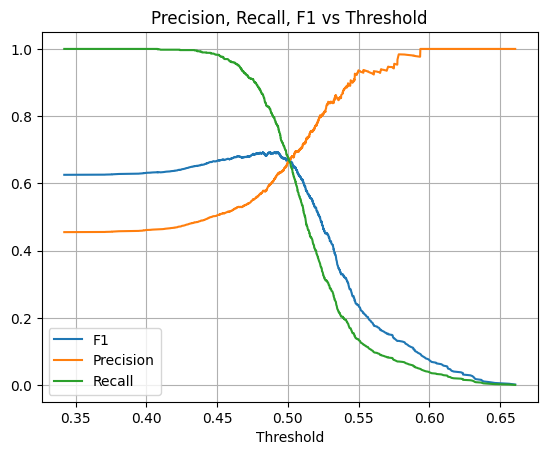

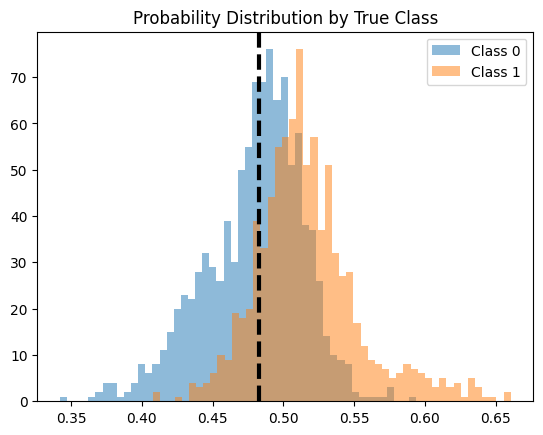

In [301]:
testing(test_result=y_train_1, test_set=X_train_1)

Best threshold: 0.42, F1 score: 0.5571


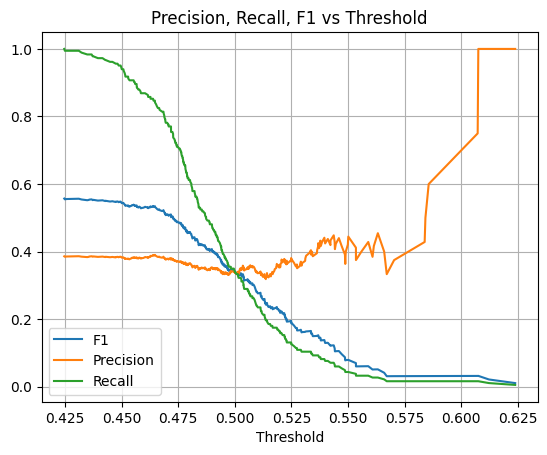

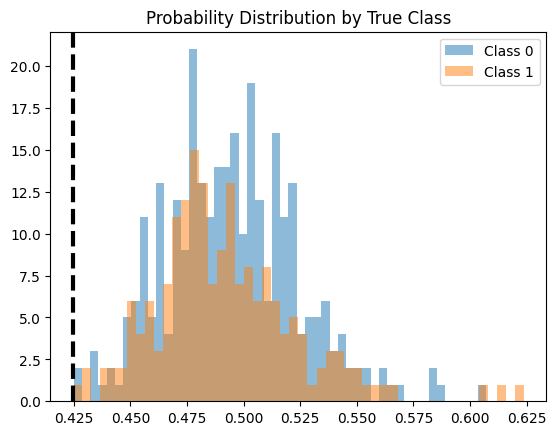

In [302]:
testing(test_result=y_test_1, test_set=X_test_1)

## Test

The Best Threshold: 0.3925161000749713


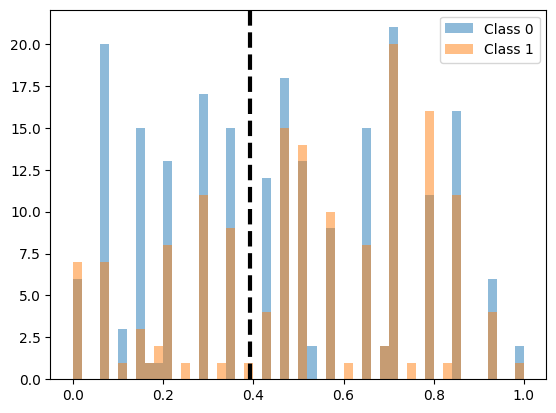

Fold 1
Train: (array([0., 1.]), array([812, 702]))
Test: (array([0., 1.]), array([218, 160]))
Prediction: (array([0., 1.]), array([143, 235])), F1: 0.55, Accurancy: 0.5264550264550265



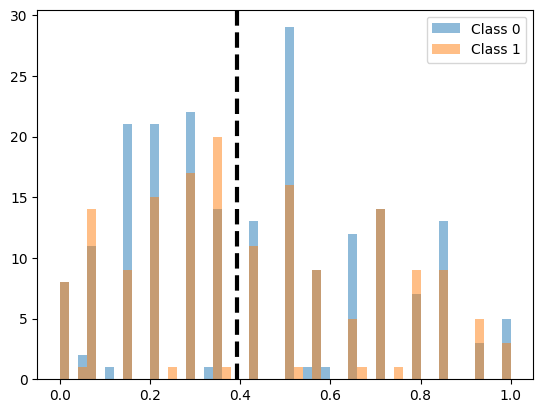

Fold 2
Train: (array([0., 1.]), array([821, 688]))
Test: (array([0., 1.]), array([208, 170]))
Prediction: (array([0., 1.]), array([187, 191])), F1: 0.47, Accurancy: 0.4894179894179894



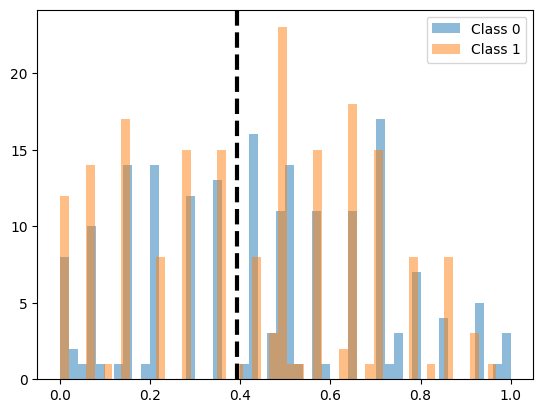

Fold 3
Train: (array([0., 1.]), array([841, 668]))
Test: (array([0., 1.]), array([187, 191]))
Prediction: (array([0., 1.]), array([159, 219])), F1: 0.53, Accurancy: 0.49206349206349204



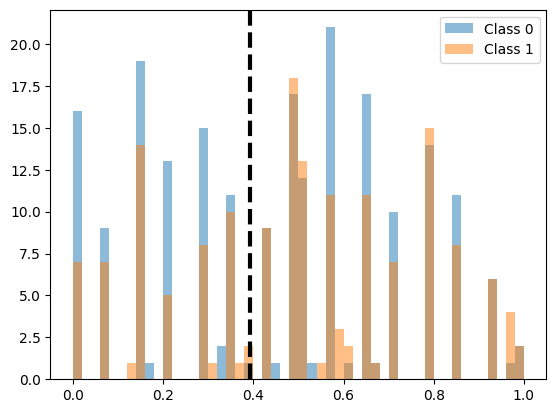

Fold 4
Train: (array([0., 1.]), array([814, 695]))
Test: (array([0., 1.]), array([211, 167]))
Prediction: (array([0., 1.]), array([143, 235])), F1: 0.55, Accurancy: 0.5238095238095238



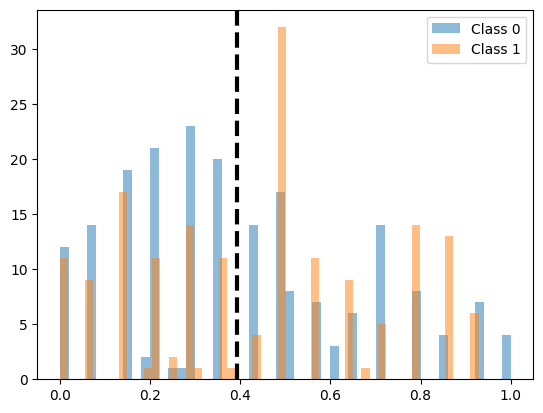

Fold 5
Train: (array([0., 1.]), array([822, 687]))
Test: (array([0., 1.]), array([205, 173]))
Prediction: (array([0., 1.]), array([191, 187])), F1: 0.53, Accurancy: 0.5502645502645502



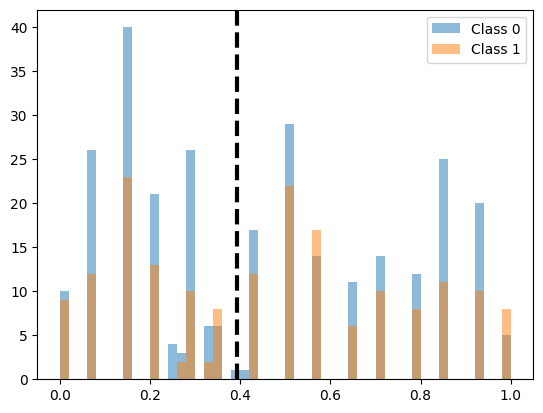


Train: (array([0., 1.]), array([1031,  862]))
Test: (array([0., 1.]), array([291, 183]))
Prediction: (array([0., 1.]), array([222, 252]))
474 474

F1: train_cv-0.5247866610155818 test-0.4781609195402299
Accurancy: train_cv-0.5164021164021164 test-0.5210970464135021
              precision    recall  f1-score   support

         0.0       0.64      0.49      0.56       291
         1.0       0.41      0.57      0.48       183

    accuracy                           0.52       474
   macro avg       0.53      0.53      0.52       474
weighted avg       0.55      0.52      0.53       474



In [303]:
Evaluation_for_Testing_part(model=base_model, threshold=best_threshold)

# Trained-Model Saving:

In [304]:
import joblib

# Save model and threshold together
package = {
    'model': tuned_model,
    'threshold': best_threshold,
    'feature set': selected_feature_set,
}

#joblib.dump(package, '/Users/sonlamtong/Desktop/Python/Thesis/Technical Analysis /ML models/prediction dataset/Classification/rf_model_with_threshold.pkl')
joblib.dump(package, '/Users/sonlamtong/Desktop/Python/Thesis/Technical Analysis /ML models/prediction dataset/Classification/rf_model_with_regimes.pkl')

['/Users/sonlamtong/Desktop/Python/Thesis/Technical Analysis /ML models/prediction dataset/Classification/rf_model_with_regimes.pkl']

# tuning model by regimes:

In [305]:
def evaluation_for_tuning_per_regimes(model, X, y, target_regime=None):
    X_train_1 = X.copy()
    y_train_1 = y.copy()
    
    '''
    res = msm_model.fit(disp=False, maxiter=500)
    proba = res.smoothed_marginal_probabilities
    proba = np.asarray(proba) if isinstance(proba, list) else proba  # guard for older versions
    regimes = proba.idxmax(axis=1).astype(int)
    '''

    f1_array_macro = []
    for fold_idx, (train_idx, test_idx) in enumerate(purged_kfold_split(X_train_1.copy())):
        X_train, X_test = X_train_1.iloc[train_idx], X_train_1.iloc[test_idx]
        y_train, y_test = y_train_1.iloc[train_idx], y_train_1.iloc[test_idx]
        
        X_train = Ensemble_Feature_Selection(model=model, X=X_train.copy(), y=y_train)
        X_test = X_test.loc[:, X_train.columns.tolist()]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
            
        f1_array_macro.append(f1_score(y_true=y_test, y_pred=y_pred))
    
    return np.mean(f1_array_macro)

def new_rf_cv(n_estimators, max_depth, min_samples_split, min_samples_leaf, max_features):
    model = RandomForestClassifier(
        n_estimators=int(n_estimators),
        max_depth=int(max_depth),
        max_features=max(min(max_features, 1.0), 0.1),
        min_samples_split=int(min_samples_split),
        min_samples_leaf=int(min_samples_leaf),
        class_weight='balanced',
        n_jobs=-1,
        random_state=42
    )

    return evaluation_for_tuning_per_regimes(model, X_train_1, y_train_1, regime)


gmm_model.fit(X[[gmm_array]].copy())
train_regime = gmm_model.predict(X[[gmm_array]].copy())
test_regime = gmm_model.predict(Valid_set[[gmm_array]].copy())

model_per_regimes = {}
for regime in np.unique(train_regime):
    
    X_train_1 = X.loc[ train_regime == regime, :].copy()
    y_train_1 = y.loc[ train_regime == regime, :].copy()
    
    rf_bo = BayesianOptimization(
        f=new_rf_cv,
        pbounds={
            "n_estimators": (50, 300),
            "max_depth": (3, 30),
            "min_samples_split": (2, 20),
            "min_samples_leaf": (1, 10),
            "max_features": (0.1, 1.0)
        },
        random_state= 42,
        verbose=2
    )
    
    rf_bo.maximize(init_points= 5, n_iter= 10)
    knn_params = rf_bo.max['params']
    
    rf_params = optimization['params']

    model_per_regimes[f"Regime {regime}"] = RandomForestClassifier(
        n_estimators=int(rf_params['n_estimators']),
        max_depth=int(rf_params['max_depth']),
        max_features=max(min(rf_params['max_features'], 1.0), 0.1),
        min_samples_leaf=int(rf_params['min_samples_leaf']),
        min_samples_split=int(rf_params['min_samples_split']),
        random_state=42,
        n_jobs= -1,
        class_weight="balanced"
    )

|   iter    |  target   | max_depth | max_fe... | min_sa... | min_sa... | n_esti... |
-------------------------------------------------------------------------------------
| 1         | 0.4309    | 13.11     | 0.9556    | 7.588     | 12.78     | 89.0      |
| 2         | 0.4409    | 7.212     | 0.1523    | 8.796     | 12.82     | 227.0     |
| 3         | 0.4418    | 3.556     | 0.9729    | 8.492     | 5.822     | 95.46     |
| 4         | 0.4289    | 7.952     | 0.3738    | 5.723     | 9.775     | 122.8     |
| 5         | 0.4643    | 19.52     | 0.2255    | 3.629     | 8.595     | 164.0     |
| 6         | 0.4497    | 13.45     | 0.722     | 3.322     | 16.98     | 202.5     |
| 7         | 0.4658    | 20.4      | 0.7931    | 3.99      | 8.114     | 162.8     |
| 8         | 0.4354    | 29.55     | 0.1889    | 5.562     | 18.13     | 159.9     |
| 9         | 0.4358    | 16.38     | 0.2982    | 5.086     | 2.281     | 161.8     |
| 10        | 0.4228    | 23.02     | 0.9904    | 5.54

## Test after Regimes Split:

In [ ]:
X_train_1 = X.copy()
y_train_1 = y.copy()

f1_array_macro = []
for fold_idx, (train_idx, test_idx) in enumerate(purged_kfold_split(X_train_1.copy())):
    X_train, X_test = X_train_1.iloc[train_idx], X_train_1.iloc[test_idx]
    y_train, y_test = y_train_1.iloc[train_idx], y_train_1.iloc[test_idx]
    
    X_train = Ensemble_Feature_Selection(model=base_model, X=X_train.copy(), y=y_train)
    X_test = X_test.loc[:, X_train.columns.tolist()]
    
    gmm_model.fit(X.iloc[train_idx][[gmm_array]].copy())
    train_regime = gmm_model.predict(X.iloc[train_idx][[gmm_array]].copy())
    test_regime = gmm_model.predict(X.iloc[test_idx][[gmm_array]].copy())
    
    the_final_ypred = np.zeros(len(X_test))
    for regime in np.unique(test_regime):

        X_train_res, y_train_res = X_train.loc[train_regime == regime], y_train.loc[train_regime == regime]
        X_test_res, y_test_res = X_test.loc[test_regime == regime], y_test.loc[test_regime == regime]
        
        model = model_per_regimes[f"Regime {regime}"]
               
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_test_res)
        the_final_ypred[test_regime == regime] = y_pred
    
        print(f"Train: {np.unique(y_train_res, return_counts=True)}")
        print(f"Test: {np.unique(y_test_res, return_counts=True)}")
        print(f"Prediction: {np.unique(y_pred, return_counts=True)}")
        print(f"Fold {fold_idx}, Regime {regime}: F1_score--{f1_score(y_test_res, y_pred)}")
        print()
    
    score = f1_score(y_true=y_test, y_pred=the_final_ypred)
    f1_array_macro.append(score)
    
    print(f"Fold {fold_idx}: F1_score--{score}")
    print()
    print()
    

np.mean(f1_array_macro)

Train: (array([0., 1.]), array([466, 405]))
Test: (array([0., 1.]), array([115,  92]))
Prediction: (array([0., 1.]), array([ 97, 110]))
Fold 0, Regime 0: F1_score--0.45544554455445546

Train: (array([0., 1.]), array([127,  72]))
Test: (array([0., 1.]), array([27, 11]))
Prediction: (array([0., 1.]), array([34,  4]))
Fold 0, Regime 1: F1_score--0.13333333333333333

Train: (array([0., 1.]), array([15, 32]))
Test: (array([0., 1.]), array([4, 4]))
Prediction: (array([1.]), array([8]))
Fold 0, Regime 2: F1_score--0.6666666666666666

Train: (array([0., 1.]), array([204, 193]))
Test: (array([0., 1.]), array([72, 53]))
Prediction: (array([0., 1.]), array([39, 86]))
Fold 0, Regime 3: F1_score--0.4460431654676259

Fold 0: F1_score--0.44565217391304346


Train: (array([0., 1.]), array([267, 228]))
Test: (array([0., 1.]), array([61, 67]))
Prediction: (array([0., 1.]), array([72, 56]))
Fold 1, Regime 0: F1_score--0.43902439024390244

Train: (array([0., 1.]), array([91, 51]))
Test: (array([0., 1.]), 

0.4921788763090861

## File Saving:

In [ ]:
import joblib

# Save model and threshold together
package = model_per_regimes
package["feature set"] = selected_feature_set

joblib.dump(package, '/Users/sonlamtong/Desktop/Python/Thesis/Technical Analysis /ML models/prediction dataset/Classification/rf_model_with_regimes_separately.pkl')

['/Users/sonlamtong/Desktop/Python/Thesis/Technical Analysis /ML models/prediction dataset/Classification/rf_model_with_regimes_separately.pkl']